In [11]:
import pandas as pd
from tcrdist.pgen import OlgaModel
from tcrdist import mappers 
from tcrdist.repertoire import TCRrep
from tcrdist.setup_tests import download_and_extract_zip_file
from tcrdist.public import _neighbors_fixed_radius

In [20]:
df = pd.read_csv(
    "/central/groups/MazmanianLab/joeB/git/tcrdist3/dash.csv"
)

tr = TCRrep(cell_df = df, 
            organism = 'mouse', 
            chains = ['alpha','beta'], 
            db_file = 'alphabeta_gammadelta_db.tsv',
            compute_distances = True)

In [22]:
# Load OLGA model as a python object
olga_beta  = OlgaModel(chain_folder = "mouse_T_beta", recomb_type="VDJ")
olga_alpha = OlgaModel(chain_folder = "mouse_T_alpha", recomb_type="VJ")

# An example computing a single Pgen
olga_beta.compute_aa_cdr3_pgen(tr.clone_df['cdr3_b_aa'][0])
olga_alpha.compute_aa_cdr3_pgen(tr.clone_df['cdr3_a_aa'][0])

# An example computing multiple Pgens 
olga_beta.compute_aa_cdr3_pgens(tr.clone_df['cdr3_b_aa'][0:5])
olga_alpha.compute_aa_cdr3_pgens(tr.clone_df['cdr3_a_aa'][0:5])

[np.float64(1.9524713788827554e-06),
 np.float64(2.0752542389986798e-07),
 np.float64(4.764594056839457e-10),
 np.float64(4.030385952124374e-05),
 np.float64(2.582201837902138e-07)]

In [23]:
# An example computing 1920 Pgens more quickly with multiple cpus
import parmap
tr.clone_df['pgen_cdr3_b_aa'] = \
    parmap.map(
        olga_beta.compute_aa_cdr3_pgen, 
        tr.clone_df['cdr3_b_aa'], 
        pm_pbar=True, 
        pm_processes = 2)

tr.clone_df['pgen_cdr3_a_aa'] = \
    parmap.map(
        olga_alpha.compute_aa_cdr3_pgen, 
        tr.clone_df['cdr3_a_aa'], 
        pm_pbar=True, 
        pm_processes = 2)

In [24]:
""""
tcrdist3's integration of Pgen estimates makes it very easy to look for
PUBLIC clusters of TCRs (i.e. high number of neighbors) with unlikely V(D)J 
recombinations.
"""
from tcrdist.public import _neighbors_fixed_radius
from tcrdist.public import _K_neighbors_fixed_radius
tr.clone_df['neighbors'] = _neighbors_fixed_radius(pwmat = tr.pw_beta, radius = 18)
tr.clone_df['K_neighbors'] = _K_neighbors_fixed_radius(pwmat = tr.pw_beta , radius = 18)
tr.clone_df['pgen_cdr3_b_aa_nlog10'] = tr.clone_df['pgen_cdr3_b_aa'].apply(lambda x : -1*np.log10(x))
tr.clone_df['nsubject'] = tr.clone_df['neighbors'].apply(lambda x: len(tr.clone_df['subject'][x].unique()))
# nsubject > 1 implies quasi-publicity
tr.clone_df['qpublic'] = tr.clone_df['nsubject'].apply(lambda x: x >1)


In [25]:
# Note one can find neighbors based on paired-chain distances.
from tcrdist.public import _neighbors_fixed_radius
from tcrdist.public import _K_neighbors_fixed_radius
tr.clone_df['neighbors'] = _neighbors_fixed_radius(pwmat = tr.pw_beta + tr.pw_alpha, radius = 50)
tr.clone_df['K_neighbors'] = _K_neighbors_fixed_radius(pwmat = tr.pw_beta + tr.pw_alpha , radius = 50)
tr.clone_df['pgen_cdr3_b_aa_nlog10'] = tr.clone_df['pgen_cdr3_b_aa'].apply(lambda x : -1*np.log10(x))
tr.clone_df['nsubject'] = tr.clone_df['neighbors'].apply(lambda x: len(tr.clone_df['subject'][x].unique()))
# nsubject > 1 implies quasi-publicity)
tr.clone_df['qpublic'] = tr.clone_df['nsubject'].apply(lambda x: x >1 )
"""
#Code for plotting pgen vs. neighbors 
import plotnine
from plotnine import ggplot, geom_point, aes, ylab, xlab
(ggplot(tr.clone_df, 
    aes(x= 'pgen_cdr3_b_aa_nlog10', 
        y ='K_neighbors',
        color = 'nsubject')) + 
    geom_point(size = .1) + 
    plotnine.scales.xlim(0,20) + 
    plotnine.facets.facet_wrap('epitope', scales = "free_y")+ ylab('Neighbors') + xlab('-Log10 Pgen'))
"""

'\n#Code for plotting pgen vs. neighbors \nimport plotnine\nfrom plotnine import ggplot, geom_point, aes, ylab, xlab\n(ggplot(tr.clone_df, \n    aes(x= \'pgen_cdr3_b_aa_nlog10\', \n        y =\'K_neighbors\',\n        color = \'nsubject\')) + \n    geom_point(size = .1) + \n    plotnine.scales.xlim(0,20) + \n    plotnine.facets.facet_wrap(\'epitope\', scales = "free_y")+ ylab(\'Neighbors\') + xlab(\'-Log10 Pgen\'))\n'

/central/groups/MazmanianLab/joeB/software/mambaforge/envs/tcrdist/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


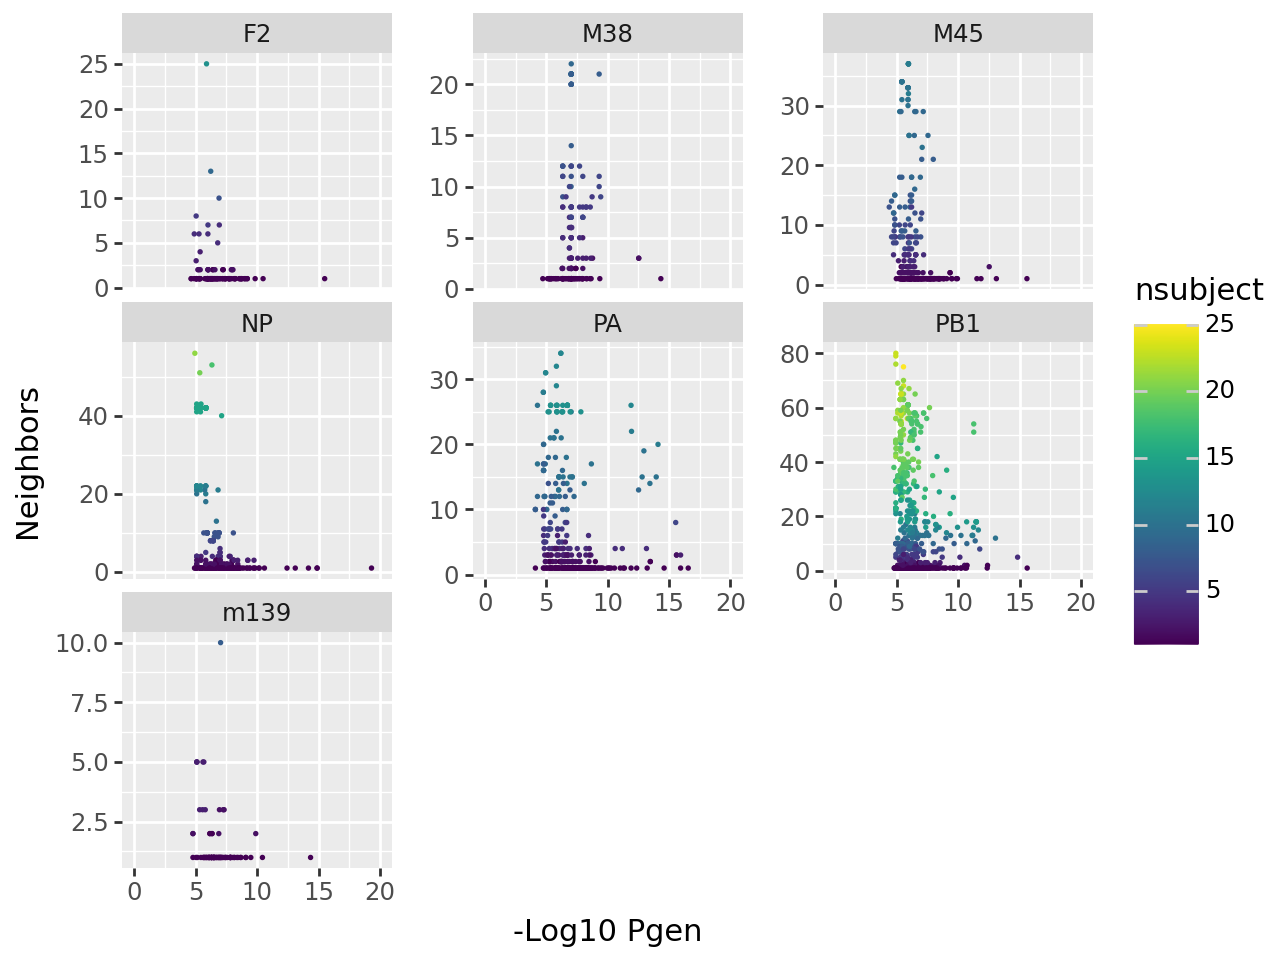

In [29]:
import plotnine
from plotnine import ggplot, geom_point, aes, ylab, xlab
(ggplot(tr.clone_df, 
    aes(x= 'pgen_cdr3_b_aa_nlog10', 
        y ='K_neighbors',
        color = 'nsubject')) + 
    geom_point(size = .1) + 
    plotnine.scales.xlim(0,20) + 
    plotnine.facets.facet_wrap('epitope', scales = "free_y")+ ylab('Neighbors') + xlab('-Log10 Pgen'))

In [30]:
tr.clone_df

,subject,epitope,v_a_gene,j_a_gene,cdr3_a_aa,cdr3_a_nucseq,v_b_gene,j_b_gene,cdr3_b_aa,cdr3_b_nucseq,...,pmhc_b_aa,count,clone_id,pgen_cdr3_b_aa,pgen_cdr3_a_aa,neighbors,K_neighbors,pgen_cdr3_b_aa_nlog10,nsubject,qpublic
0,mouse_subject0001,F2,TRAV14-1*01,TRAJ21*01,CAARPSNYNVLYF,tgtgcagcaaggccgtctaattacaacgtgctttacttc,TRBV14*01,TRBJ2-5*01,CAIGSNQDTQYF,tgtgccataggcagtaaccaagacacccagtacttt,...,P.KGTN,1,1,1.677651e-08,1.952471e-06,[0],1,7.775298,1,False
1,mouse_subject0001,F2,TRAV14D-3/DV8*01,TRAJ9*02,CAASEGGYKLTF,tgtgcagcaagtgaggggggctacaaacttaccttc,TRBV19*03,TRBJ1-6*01,CASRPDISYNSPLYF,tgtgccagcaggcctgacatttcctataattcgcccctctacttt,...,E.KKSS,2,2,1.560754e-08,2.075254e-07,[1],1,7.806666,1,False
2,mouse_subject0001,F2,TRAV14D-3/DV8*02,TRAJ47*01,CASPGGDYANKMIF,tgtgcatccccagggggggactatgcaaacaagatgatcttt,TRBV19*01,TRBJ2-7*01,CASSIGQDEQYF,tgtgccagcagtatagggcaggatgaacagtacttc,...,E.KKSS,1,3,3.054308e-07,4.764594e-10,[2],1,6.515087,1,False
3,mouse_subject0001,F2,TRAV3-1*01,TRAJ15*01,CAGQGGRALIF,tgcgcaggccagggaggcagagctctgatattt,TRBV29*01,TRBJ2-5*01,CASSLFQIQDTQYF,tgtgctagcagtttattccagatccaagacacccagtacttt,...,K.KREH,1,4,6.762318e-09,4.030386e-05,[3],1,8.169904,1,False
4,mouse_subject0001,F2,TRAV5-4*01,TRAJ40*01,CAASDGTGNYKYVF,tgtgctgcaagtgacggtacaggaaactacaaatacgtcttt,TRBV19*03,TRBJ2-7*01,CASSPGTTYEQYF,tgtgccagcagtcccgggacaacctatgaacagtacttc,...,E.KKSS,1,5,9.966586e-07,2.582202e-07,"[4, 217]",2,6.001454,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,mouse_subject0078,PB1,TRAV3D-3*02,TRAJ26*01,CAVSGNYAQGLTF,tgcgcagtcagtggtaactatgcccagggattaaccttc,TRBV4*01,TRBJ1-4*01,CASSGDSNERLFF,tgtgccagcagtggggattccaacgaaagattatttttc,...,S.DKAH,1,1916,3.614750e-06,2.974514e-05,"[304, 330, 335, 360, 393, 530, 632, 719, 722, ...",27,5.441922,19,True
1916,mouse_subject0078,PB1,TRAV3D-3*02,TRAJ26*01,CAVSLNYAQGLTF,tgcgcagtcagccttaactatgcccagggattaaccttc,TRBV4*01,TRBJ2-3*01,CASSGDSAETLYF,tgtgccagcagtggggatagtgcagaaacgctgtatttt,...,S.DKAH,2,1917,4.694196e-06,6.358213e-06,"[291, 304, 330, 335, 360, 364, 366, 384, 387, ...",59,5.328439,20,True
1917,mouse_subject0078,PB1,TRAV3D-3*02,TRAJ26*01,CAVSNNYAQGLTF,tgcgcagtcagtaataactatgcccagggattaaccttc,TRBV19*03,TRBJ2-3*01,CASSDSSAETLYF,tgtgccagcagtgactctagtgcagaaacgctgtatttt,...,E.KKSS,1,1918,4.325883e-06,3.621388e-05,"[333, 363, 538, 540, 720, 725, 752, 757, 801, ...",26,5.363925,15,True
1918,mouse_subject0078,PB1,TRAV3D-3*02,TRAJ26*01,CAVSVNYAQGLTF,tgcgcagtcagtgttaactatgcccagggattaaccttc,TRBV14*01,TRBJ2-3*01,CASSPDSAETLYF,tgtgccagcagtcccgacagtgcagaaacgctgtatttt,...,P.KGTN,1,1919,5.278607e-06,9.077699e-06,"[289, 293, 306, 329, 378, 383, 391, 394, 395, ...",41,5.277481,20,True
